# Usecase 3: CRC classification — original baseline

Trains a Random Forest baseline with 5-fold stratified CV on the same train/test split as the ritme run, following [Topcuoğlu et al. 2020](https://doi.org/10.1128/mBio.00434-20): per-OTU min-max-scaled subsampled OTU abundances fed to a `RandomForestClassifier`. Random Forest was Topcuoğlu's best-AUROC model (0.695, IQR 0.650–0.739 over 100 random splits).

Two small deviations from Topcuoğlu, both documented:
1. **Single 80/20 split** instead of 100 random splits (matches ritme's protocol; Topcuoğlu's variability across splits is captured by the bootstrap CI on this one split).
2. **Min-max scaler fit on train only** (Topcuoğlu fit on the full dataset; we hold the test set out to avoid leakage).

This notebook can be run in the following conda environment (the last command must be launched from the root of this repository):
```shell
mamba create -n ritme_usecases -c adamova -c conda-forge -c bioconda -c pytorch ritme ipykernel nbconvert -y
conda activate ritme_usecases
pip install -e .
```

## Setup

In [1]:
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler

from src.bootstrap_metrics import bootstrap_classification_metrics
from src.eval_originals import (
    get_metrics_n_roc_curve,
    load_baseline_split,
)

os.makedirs("../result_figures", exist_ok=True)

## Load the same split ritme used

In [2]:
data_splits_folder = "data_splits_u3"
path_to_baxter_ft = "../../data/u3_topcuoglu20_baxter/otu_table_baxter_subsampled.tsv"
path_to_baxter_md = "../../data/u3_topcuoglu20_baxter/md_baxter.tsv"
target = "srn"

X_train, y_train, X_test, y_test = load_baseline_split(
    data_splits_folder,
    path_to_baxter_ft,
    path_to_baxter_md,
    target,
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print(
    "Train SRN prevalence:",
    float(y_train.mean()).__round__(3),
    "| Test SRN prevalence:",
    float(y_test.mean()).__round__(3),
)

Train: (392, 6920) Test: (98, 6920)
Train SRN prevalence: 0.467 | Test SRN prevalence: 0.469


## Per-OTU min-max normalization

Per-OTU min-max rescaling. Fit on train and clamp test to [0, 1] (Topcuoğlu fit on the full dataset; we hold the test set out, see deviation note above).

In [3]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), index=X_test.index, columns=X_test.columns
).clip(lower=0, upper=1)

## Train and tune Random Forest

5-fold stratified CV with AUROC objective; hyperparameter grid (see cell below) follows Topcuoğlu's RF defaults.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)
param_grid = {
    "max_features": ["sqrt", "log2", 0.05, 0.1],
    "min_samples_leaf": [1, 5],
}
base_rf = RandomForestClassifier(n_estimators=500, random_state=12, n_jobs=-1)
search = GridSearchCV(base_rf, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
search.fit(X_train_scaled, y_train)
rf_model = search.best_estimator_
print("Best CV AUROC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Best CV AUROC: 0.6792
Best params: {'max_features': 'log2', 'min_samples_leaf': 1}


## Evaluate on train + test

,auroc_train,accuracy_train,f1_train,precision_train,recall_train,auroc_test,accuracy_test,f1_test,precision_test,recall_test
original,1.0,1.0,1.0,1.0,1.0,0.697115,0.642857,0.520548,0.703704,0.413043


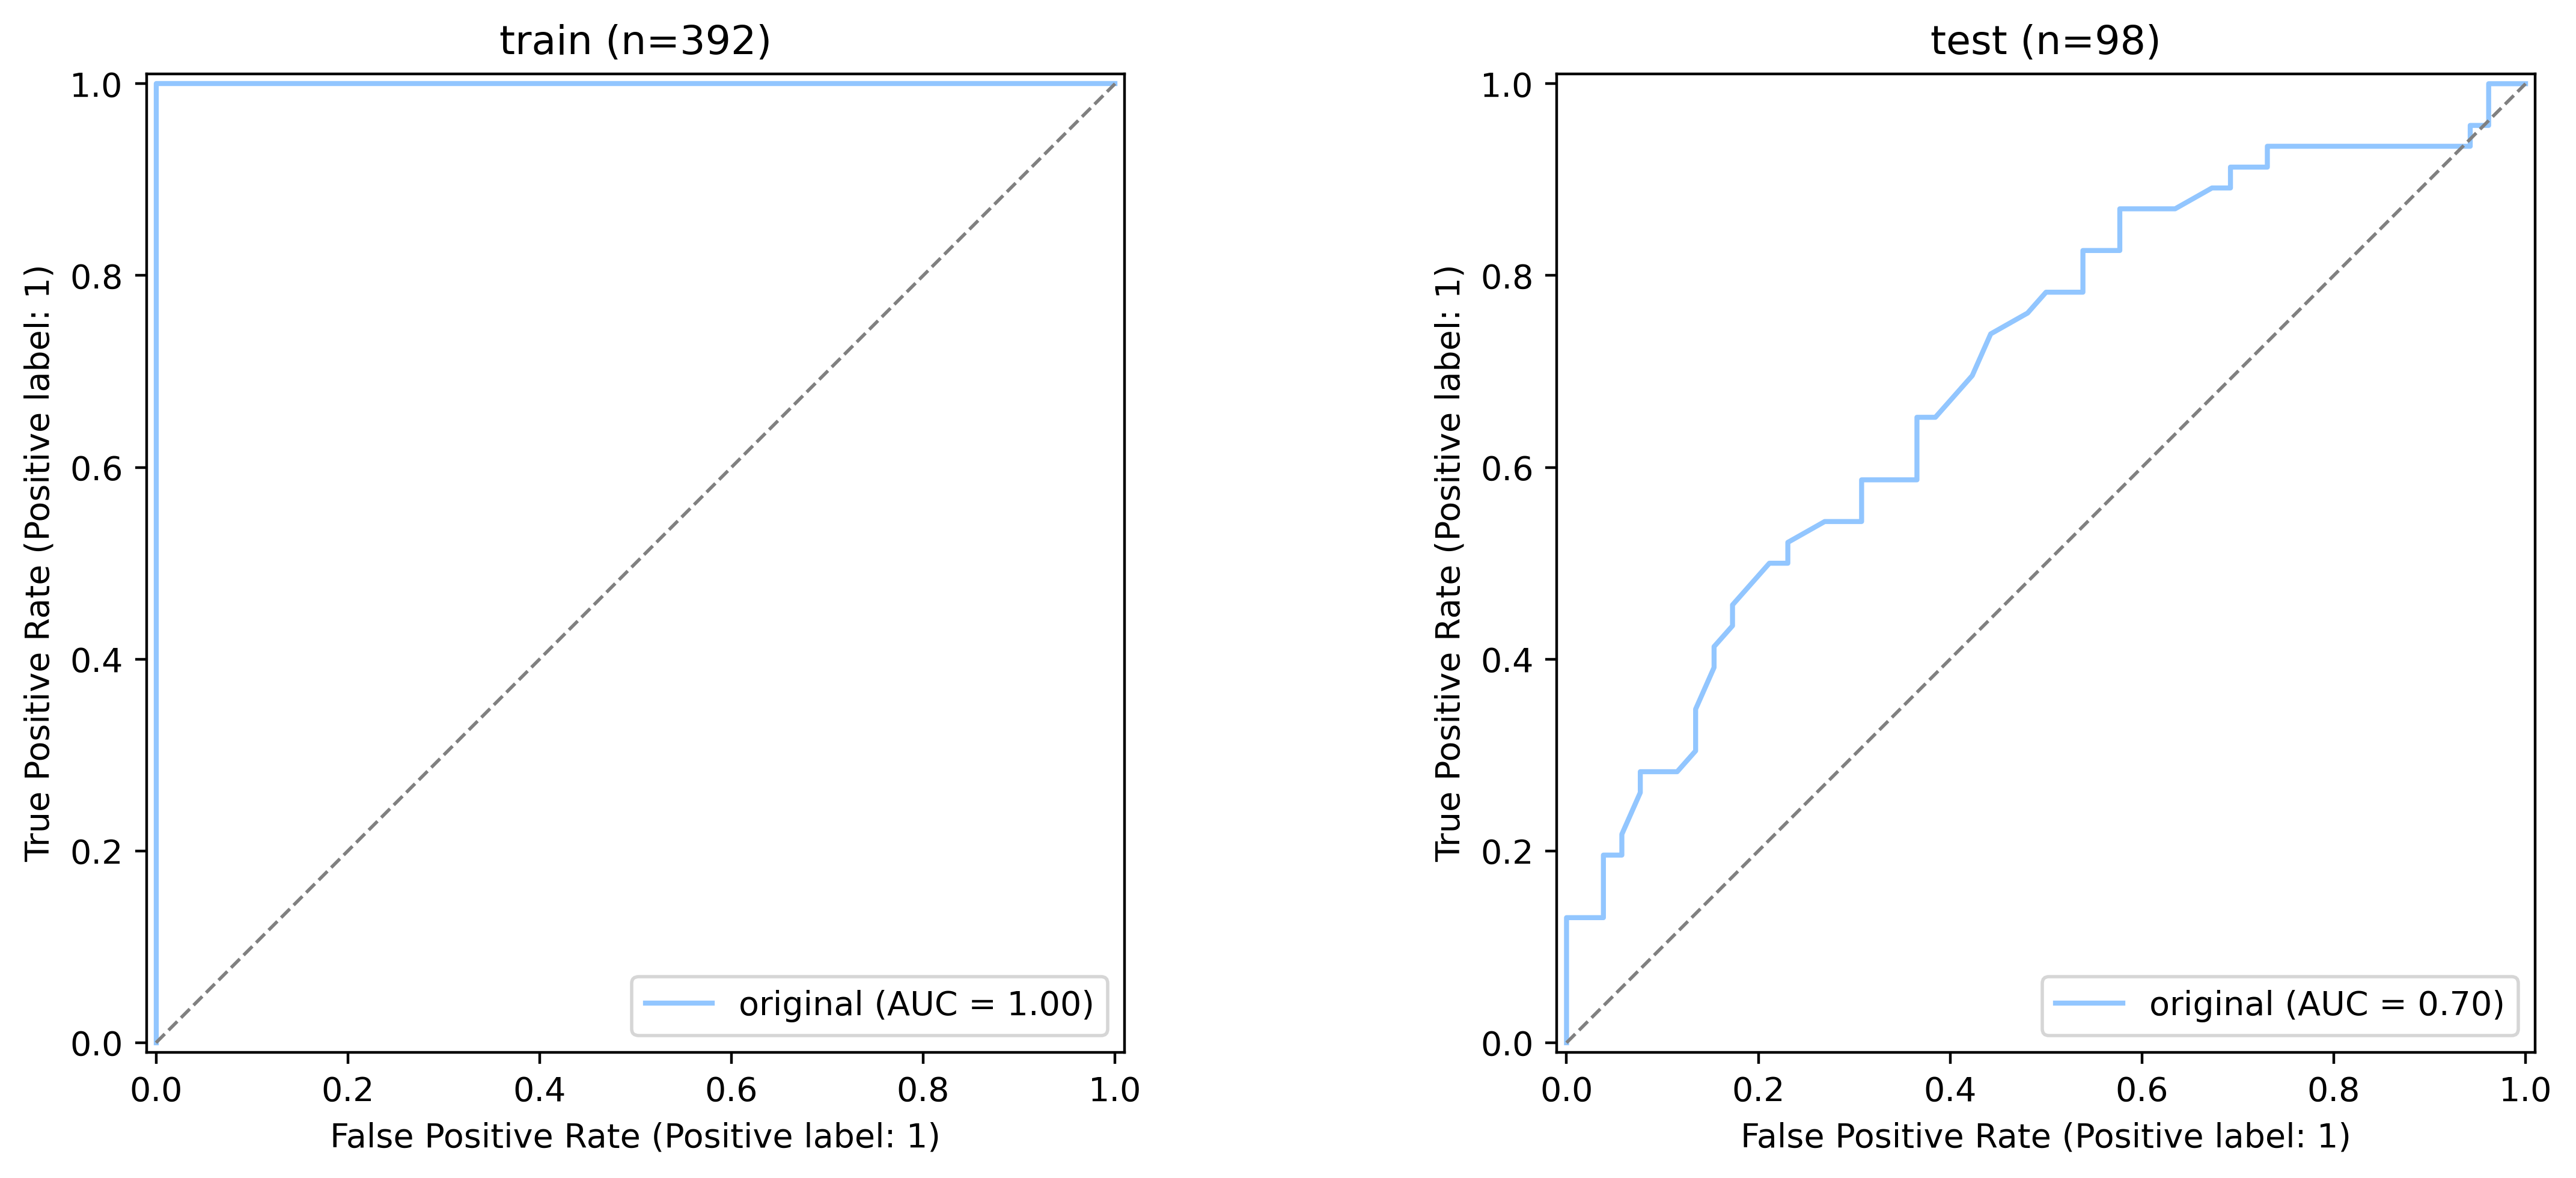

In [5]:
metrics, fig = get_metrics_n_roc_curve(
    rf_model,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)
metrics

## Bootstrap 95% CI on test metrics

Resamples the held-out test rows 1000 times, recomputes AUROC / accuracy / F1 / precision / recall on each resample, and reports the percentile CI alongside the point estimate. Saved to `../result_figures/` so it can be picked up by `evaluate_all_trials.ipynb`.

In [6]:
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)
boot = bootstrap_classification_metrics(y_test.to_numpy(), y_test_proba, y_test_pred)
boot.to_csv("../result_figures/bootstrap_test_metrics_u3_original.csv", index=False)
print(boot.to_string(index=False))

        metric    point     mean   ci_low  ci_high  n_resamples  ci_pct
    auroc_test 0.697115 0.699497 0.599700 0.795138         1000    0.95
 accuracy_test 0.642857 0.643092 0.551020 0.734694         1000    0.95
       f1_test 0.520548 0.519056 0.371429 0.650602         1000    0.95
precision_test 0.703704 0.705700 0.545360 0.857143         1000    0.95
   recall_test 0.413043 0.414749 0.270833 0.566102         1000    0.95


In [7]:
fig.savefig("../result_figures/best_roc_u3_original.pdf", bbox_inches="tight", dpi=400)